In [1]:
from math import factorial

import numpy as np
import matplotlib.pyplot as plt
import qutip as qt

from plots import *
from src import Transducer, aout_moments, Phi_fock, Phi_coherent, fidelity

# Enable SVG in Jupyter notebooks.
%config InlineBackend.figure_formats = ['svg']

# Microwave-optical transduction fidelity &mdash; sanity check

`2_transduction.ipynb` gets the transduction fidelity from `src/fidelity.py` (output characteristic function, App. F, 2D quadrature). Here we recompute it straight from the input-output relation as an operator expectation value, for both number-state and coherent-state inputs.

For a number state the fidelity is the overlap probability of the transduced optical field with the target,

$$
\mathcal{F}_n 
= 
\langle n|
\rho_\mathrm{out}
|n\rangle
.
$$

Since $\hat{a}_\mathrm{out}$ mixes several input modes, we take this diagonal element from
the number-state projector in normal-ordered form:

$$
|n\rangle \langle n| 
= 
\sum_{m\ge n}
\frac{(-1)^{m-n}}{(m-n)!n!}
(\hat{a}^\dagger)^m \hat{a}^m
\quad\Longrightarrow\quad
\mathcal{F}_n 
= 
\sum_{m\ge n}
\frac{(-1)^{m-n}}{(m-n)!n!}
\big\langle 
(\hat{a}_\mathrm{out}^\dagger)^m (\hat{a}_\mathrm{out})^m 
\big\rangle 
.
$$

Here the expectation value is taken with respect to the input state.

### The number-state projector in normal-ordered form

The identity above follows from the generating function (Cahill &amp; Glauber, Phys. Rev.
**177**, 1857 (1969), Eqs. (4.35)&ndash;(4.36); equivalently `a.pdf` Eq. (53)):

$$
{:}e^{-\lambda\,\hat{a}^\dagger\hat{a}}{:}
=
\sum_{n\ge 0}(1-\lambda)^n |n\rangle \langle n|
=
\sum_{m\ge 0}\frac{(-\lambda)^m}{m!} \hat{a}^{\dagger m} \hat{a}^m
$$

Expanding $(1-\lambda)^n = \sum_{j=0}^{n} \binom{n}{j} (-\lambda)^j$, 

$$
\sum_{n\ge 0} \left( \sum_{j=0}^{n} \binom{n}{j} (-\lambda)^j \right) |n\rangle \langle n| 
=
\sum_{m\ge 0} \frac{(-\lambda)^m}{m!} \hat{a}^{\dagger m} \hat{a}^m
.
$$

Matching the coefficient of $(-\lambda)^m$ to each side gives us

$$
\sum_{n\ge m} \binom{n}{m} |n\rangle \langle n| 
=
\frac{1}{m!} \hat{a}^{\dagger m} \hat{a}^m
.
$$

Finally, we invert the binomial to obtain

$$
|n\rangle \langle n| 
=
\sum_{m\ge n} (-1)^{m-n} \binom{m}{n}
\frac{1}{m!} \hat{a}^{\dagger m} \hat{a}^m
=
\sum_{m\ge n} \frac{(-1)^{m-n}}{(m-n)!n! }
\hat{a}^{\dagger m} \hat{a}^m
.
$$

### The coherent-state projector

Displacing the $n=0$ identity (`a.pdf` Eq. (54): $D(\hat{a},\alpha)\,{:}e^{-\lambda\hat{a}^\dagger\hat{a}}{:}\,D^\dagger(\hat{a},\alpha)$ at $\lambda = 1$) gives

$$
|\alpha\rangle \langle\alpha|
=
{:}\exp\!\big[-(\hat{a}^\dagger - \alpha^*)(\hat{a} - \alpha)\big]{:}
=
\sum_{k\ge 0} \frac{(-1)^k}{k!}
(\hat{a}^\dagger - \alpha^*)^k (\hat{a} - \alpha)^k
,
$$

so with $\alpha = \sqrt{\bar{n}}$ and the input $|\alpha\rangle_{b_\mathrm{in}} \otimes \mathrm{vac}$,

$$
\mathcal{F}_\alpha
=
\langle\alpha| \rho_\mathrm{out} |\alpha\rangle
=
\sum_{k\ge 0} \frac{(-1)^k}{k!}
\big\| (\hat{a}_\mathrm{out} - \alpha)^k \, |\psi_\mathrm{in}\rangle \big\|^2
.
$$

The series converges within a few terms &mdash; the raising content of $\hat{a}_\mathrm{out}$ carries the tiny coefficient $S_{14}$ &mdash; so the signal mode only needs Hilbert space for the coherent state plus those few ladder steps. At $\eta = 1$ the deterministic gain is unity and $\mathcal{F}_\alpha$ does not depend on $\alpha$; the dependence appears once $\eta < 1$.

In [2]:
params = {
    'kappa_a' : 13.2,   # Optical linewidth [2π * GHz].
    'kappa_b' : 0.002,  # Microwave linewidth [2π * GHz].
    'omega_b' : 5.0,    # Microwave frequency [2π * GHz].
    'Delta' : 5.0,      # Optical detuning [2π * GHz].
    'eta_a' : 0.9,      # Optical collection efficiency (< 1 so F_alpha varies with nbar).
    'eta_b' : 0.9,      # Microwave collection efficiency.
}

Delta_a = 0.2                                               # Optical detuning [2π * GHz].
z = 1 / abs(1 - (params['omega_b']/Delta_a)**2)             # Parametric coupling ratio from Eq. (24).

g_t = np.sqrt(params['kappa_a'] * params['kappa_b']) / 2    # Transduction rate.
g_s = z * g_t                                               # Two-mode squeezing rate.

In [3]:
# Initialise the transducer.
transducer = Transducer(**params)

# Noise moments at the central frequency.
S, L = transducer.channel(params['omega_b'], g_t, g_s)
moments = aout_moments(S, L)

# Extract the first rows of the matrices.
S_11, S_12, S_13, S_14 = S[0]
L_11, L_12, L_13, L_14 = L[0]

The output optical field, Eq. (app-eqn:aout):

$$\hat{a}_\mathrm{out} =
S_{12}\hat{b}_\mathrm{in} + S_{14}\hat{b}_\mathrm{in}^\dagger
+ S_{11}\hat{a}_\mathrm{in} + S_{13}\hat{a}_\mathrm{in}^\dagger
+ L_{11}\hat{\xi}_a + L_{12}\hat{\xi}_b + L_{13}\hat{\xi}_a^\dagger + L_{14}\hat{\xi}_b^\dagger .$$

$\hat{b}_\mathrm{in}$ carries the input state; $\hat{a}_\mathrm{in}$, $\hat{\xi}_a$,
$\hat{\xi}_b$ are in vacuum.

In [4]:
def optical_output_mode(dims):
    """
    Optical output mode operator a_out on the four-mode Hilbert space.

    Arguments
    ---------
    dims : int or sequence of 4 ints
        Hilbert-space dimension per mode, ordered (a_in, b_in, xi_a, xi_b).
        A scalar uses the same dimension for every mode.
    """

    if np.isscalar(dims):
        dims = (dims,) * 4

    # Annihilation operator for mode k, identity on the other three modes.
    def mode(k):
        ops = [qt.qeye(dim) for dim in dims]
        ops[k] = qt.destroy(dims[k])
        return qt.tensor(ops)

    a_in, b_in, xi_a, xi_b = mode(0), mode(1), mode(2), mode(3)

    # Linear combination of input and noise operators, Eq. (app-eqn:aout).
    return (
        S_12 * b_in + S_14 * b_in.dag()
        + S_11 * a_in + S_13 * a_in.dag()
        + L_11 * xi_a + L_12 * xi_b + L_13 * xi_a.dag() + L_14 * xi_b.dag()
        )


def fock_fidelity(n, d):
    """
    Number-state fidelity F_n = <n|rho_out|n> from the normal-ordered projector,

        F_n = Σ_{m≥n} (-1)^{m-n}/((m-n)! n!) ‖ a_out^m |n>_{b_in} ⊗ vacuum ‖².

    Arguments
    ---------
    n : int
        Fock state number.
    d : int
        Hilbert-space dimension per mode.
    """

    a_out = optical_output_mode(d)

    # Input state: |n> in the b_in mode, vacuum elsewhere.
    psi = qt.tensor(qt.basis(d, 0), qt.basis(d, n), qt.basis(d, 0), qt.basis(d, 0))

    F = 0.0
    for m in range(n + 20):
        if m >= n:
            F += (-1)**(m-n) / (factorial(m-n) * factorial(n)) * psi.norm()**2
        psi = a_out * psi

    return F


def coherent_fidelity(nbar, K=8):
    """
    Coherent-state fidelity F_alpha = <alpha|rho_out|alpha>, alpha = sqrt(nbar),
    from the displaced projector (a.pdf Eq. 54),

        F_alpha = Σ_{k≥0} (-1)^k/k! ‖ (a_out - alpha)^k |alpha>_{b_in} ⊗ vacuum ‖².

    Arguments
    ---------
    nbar : float
        Mean photon number of the coherent input.
    K : int
        Number of terms kept in the series (a handful is plenty).
    """

    alpha = np.sqrt(nbar)

    # Signal mode: room for the coherent state plus the K ladder steps.
    # Vacuum modes: only ever K-excited.
    d_sig = int(nbar + 10*np.sqrt(nbar)) + 3*K + 12
    d_vac = K + 3

    a_out = optical_output_mode((d_vac, d_sig, d_vac, d_vac))
    shift = a_out - alpha * qt.qeye([d_vac, d_sig, d_vac, d_vac])

    # Input state: |alpha> in the b_in mode, vacuum elsewhere.
    psi = qt.tensor(
        qt.basis(d_vac, 0), qt.coherent(d_sig, alpha), qt.basis(d_vac, 0), qt.basis(d_vac, 0)
        )

    F = 0.0
    for k in range(K):
        F += (-1)**k / factorial(k) * psi.norm()**2
        psi = shift * psi

    return F

In [5]:
n_fock = np.arange(1, 16)              # Number states (integer photon number).
nbar_coh = np.linspace(1.0, 15.0, 15)  # Coherent states (mean photon number).

# Number-state fidelity: operator series vs. characteristic-function reference.
F_fock = np.array([fock_fidelity(n, d=n+6) for n in n_fock])
F_fock_ref = np.array([fidelity(lambda w: Phi_fock(w, n), *moments) for n in n_fock])

# Coherent-state fidelity: operator series vs. characteristic-function reference.
F_coh = np.array([coherent_fidelity(nbar) for nbar in nbar_coh])
F_coh_ref = np.array([fidelity(lambda w: Phi_coherent(w, np.sqrt(nbar)), *moments) for nbar in nbar_coh])

print(f"max |F_op - F_ref|, number states:   {np.abs(F_fock - F_fock_ref).max():.2e}")
print(f"max |F_op - F_ref|, coherent states: {np.abs(F_coh - F_coh_ref).max():.2e}")

max |F_op - F_ref|, number states:   4.27e-13
max |F_op - F_ref|, coherent states: 6.21e-12


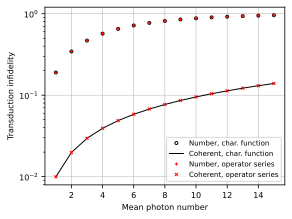

In [6]:
fig, axs = plt.subplots(
    nrows = 1,
    ncols = 1,
    figsize = (
        1.2 * FIG_SIZES['onecol'],
        0.9 * FIG_SIZES['onecol']
        ),
    )

# Characteristic-function reference (src/fidelity.py).
axs.plot(n_fock, 1-F_fock_ref, 'ko', mfc='none', label='Number, char. function')
axs.plot(nbar_coh, 1-F_coh_ref, 'k-', label='Coherent, char. function')

# Operator expectation value (this notebook).
axs.plot(n_fock, 1-F_fock, 'r+', label='Number, operator series')
axs.plot(nbar_coh, 1-F_coh, 'rx', label='Coherent, operator series')

axs.semilogy()
axs.grid('both')

axs.set_xlabel('Mean photon number')
axs.set_ylabel('Transduction infidelity')
axs.legend(loc='lower right')

fig.tight_layout()
fig.savefig('fig/sanity_check.pdf', bbox_inches='tight')